# NHANES Pulse Consumption — Replication Analysis

Replicates key findings from Drewnowski et al. (2025) *Frontiers in Nutrition*:
- Consumer prevalence by demographics
- Mean consumption amounts (oz equivalents/day)
- Table 1: Characteristics of pulse consumers vs non-consumers
- Consumption by pulse type

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA_DIR, 'derived')

df = pd.read_parquet(os.path.join(DERIVED, 'pulse_consumption.parquet'))
print(f'Loaded {len(df):,} participants')
print(f'Cycles: {df["CYCLE"].nunique()}')
print(f'Consumers: {df["IS_CONSUMER"].sum():,} ({100*df["IS_CONSUMER"].mean():.1f}%)')

Loaded 48,736 participants
Cycles: 10
Consumers: 10,174 (20.9%)


## Survey-weighted estimates

The paper uses NHANES survey weights (WTDRD1 for dietary day 1) and
design variables (SDMVSTRA, SDMVPSU) for nationally representative estimates.

For 10 pooled cycles, the weight is WTDRD1/10 (one-tenth of the 2-year weight).

In [2]:
# Create 10-cycle pooled weight
n_cycles = df['CYCLE'].nunique()
df['WT_POOLED'] = df['WTDRD1'] / n_cycles

# Drop rows with missing weights
has_wt = df['WT_POOLED'].notna() & (df['WT_POOLED'] > 0)
print(f'Participants with valid WTDRD1: {has_wt.sum():,} / {len(df):,}')

def weighted_mean(values, weights):
    """Compute weighted mean, ignoring NaN."""
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def weighted_pct(binary, weights):
    """Compute weighted percentage."""
    return 100 * weighted_mean(binary, weights)

def weighted_ci(values, weights, alpha=0.05):
    """Bootstrap-free approximate CI for weighted mean using linearization."""
    mask = values.notna() & weights.notna() & (weights > 0)
    v = values[mask].values
    w = weights[mask].values
    wm = np.average(v, weights=w)
    # Weighted variance
    n_eff = (w.sum())**2 / (w**2).sum()  # effective sample size
    wvar = np.average((v - wm)**2, weights=w)
    se = np.sqrt(wvar / n_eff)
    z = stats.norm.ppf(1 - alpha/2)
    return wm - z*se, wm + z*se

Participants with valid WTDRD1: 48,736 / 48,736


## Overall prevalence and consumption

Paper reports:
- 17.2% consumed any pulses on a given day
- Mean consumption: 0.39 oz eq/day (all), 2.26 oz eq/day (consumers)

In [3]:
dfw = df[has_wt].copy()
consumers_w = dfw[dfw['IS_CONSUMER'] == 1]

prev_wt = weighted_pct(dfw['IS_CONSUMER'], dfw['WT_POOLED'])
mean_oz_all = weighted_mean(dfw['PULSE_OZ_EQ'], dfw['WT_POOLED'])
mean_oz_cons = weighted_mean(consumers_w['PULSE_OZ_EQ'], consumers_w['WT_POOLED'])

print('=== Weighted (nationally representative) estimates ===')
print(f'Consumer prevalence: {prev_wt:.1f}% (paper: 17.2%)')
print(f'Mean oz eq/day (all): {mean_oz_all:.2f} (paper: 0.39)')
print(f'Mean oz eq/day (consumers): {mean_oz_cons:.2f} (paper: 2.26)')

print(f'\n=== Unweighted estimates ===')
print(f'Consumer prevalence: {100*dfw["IS_CONSUMER"].mean():.1f}%')
print(f'Mean oz eq/day (all): {dfw["PULSE_OZ_EQ"].mean():.2f}')
print(f'Mean oz eq/day (consumers): {consumers_w["PULSE_OZ_EQ"].mean():.2f}')

=== Weighted (nationally representative) estimates ===
Consumer prevalence: 18.9% (paper: 17.2%)
Mean oz eq/day (all): 0.47 (paper: 0.39)
Mean oz eq/day (consumers): 2.46 (paper: 2.26)

=== Unweighted estimates ===
Consumer prevalence: 20.9%
Mean oz eq/day (all): 0.56
Mean oz eq/day (consumers): 2.66


## Prevalence by race/ethnicity

Paper: Mexican Americans 33.3%, Non-Hispanic Black 12.0%

In [4]:
print('Consumer prevalence by race/ethnicity (weighted):')
print(f'{"Group":<25s} {"Prev %":>8s}  {"n":>6s}  {"consumers":>10s}')
print('-' * 55)
for grp in ['Mexican American', 'Non-Hispanic White', 'Non-Hispanic Black', 'Other']:
    mask = dfw['RACE_ETH'] == grp
    sub = dfw[mask]
    prev = weighted_pct(sub['IS_CONSUMER'], sub['WT_POOLED'])
    n_cons = sub['IS_CONSUMER'].sum()
    print(f'{grp:<25s} {prev:>7.1f}%  {len(sub):>6,}  {n_cons:>10,}')

print(f'\nPaper: Mexican American 33.3%, NH Black 12.0%')

Consumer prevalence by race/ethnicity (weighted):
Group                       Prev %       n   consumers
-------------------------------------------------------
Mexican American             35.3%   8,556       3,181


Non-Hispanic White           16.8%  21,865       3,380
Non-Hispanic Black           13.9%  10,193       1,389
Other                        24.9%   8,122       2,224

Paper: Mexican American 33.3%, NH Black 12.0%


## Prevalence by cycle (temporal trends)

In [5]:
cycle_stats = []
for cycle in sorted(dfw['CYCLE'].unique()):
    sub = dfw[dfw['CYCLE'] == cycle]
    # Use 2-year weight for per-cycle estimates
    prev = weighted_pct(sub['IS_CONSUMER'], sub['WTDRD1'])
    mean_oz = weighted_mean(sub['PULSE_OZ_EQ'], sub['WTDRD1'])
    cons = sub[sub['IS_CONSUMER'] == 1]
    mean_oz_c = weighted_mean(cons['PULSE_OZ_EQ'], cons['WTDRD1'])
    lo, hi = weighted_ci(sub['IS_CONSUMER'], sub['WTDRD1'])
    cycle_stats.append({
        'Cycle': cycle, 'N': len(sub), 'n_consumers': cons.shape[0],
        'Prevalence %': prev, 'Prev_lo': 100*lo, 'Prev_hi': 100*hi,
        'Mean oz eq (all)': mean_oz, 'Mean oz eq (consumers)': mean_oz_c
    })

cycle_df = pd.DataFrame(cycle_stats)
print(cycle_df.to_string(index=False, float_format='%.1f'))

    Cycle    N  n_consumers  Prevalence %  Prev_lo  Prev_hi  Mean oz eq (all)  Mean oz eq (consumers)
1999-2000 4237          956          18.3     16.6     20.0               0.5                     2.6
2001-2002 4744          968          18.3     16.8     19.8               0.5                     2.6
2003-2004 4448          906          18.2     16.6     19.8               0.4                     2.4
2005-2006 4520          881          16.4     14.9     17.9               0.4                     2.5
2007-2008 5419         1058          17.5     16.1     19.0               0.4                     2.5
2009-2010 5762         1130          17.3     15.9     18.6               0.4                     2.6
2011-2012 4801         1061          21.7     19.9     23.4               0.5                     2.5
2013-2014 5047         1066          19.5     18.1     21.0               0.5                     2.3
2015-2016 5017         1185          21.6     19.8     23.3               0.5     

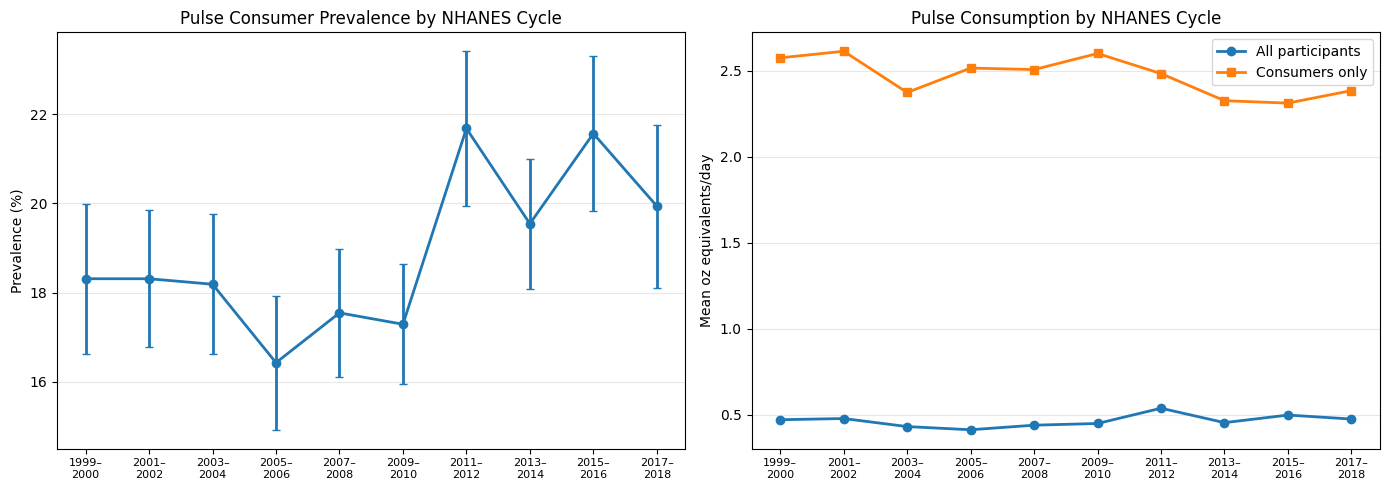

In [6]:
# Plot temporal trend in prevalence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(cycle_df))
labels = [c.replace('-', '–\n') for c in cycle_df['Cycle']]

ax1.errorbar(x, cycle_df['Prevalence %'],
             yerr=[cycle_df['Prevalence %'] - cycle_df['Prev_lo'],
                   cycle_df['Prev_hi'] - cycle_df['Prevalence %']],
             marker='o', capsize=3, linewidth=2)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylabel('Prevalence (%)')
ax1.set_title('Pulse Consumer Prevalence by NHANES Cycle')
ax1.grid(axis='y', alpha=0.3)

ax2.plot(x, cycle_df['Mean oz eq (all)'], 'o-', label='All participants', linewidth=2)
ax2.plot(x, cycle_df['Mean oz eq (consumers)'], 's-', label='Consumers only', linewidth=2)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel('Mean oz equivalents/day')
ax2.set_title('Pulse Consumption by NHANES Cycle')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Table 1: Characteristics of pulse consumers vs non-consumers

Replicating the paper's Table 1 (screenshot):
- Stratified by consumer status
- Unweighted sample sizes, weighted percentages with 95% CIs
- Chi-square test p-values

In [7]:
def make_table1_row(var_name, categories, data, wt_col='WT_POOLED'):
    """Build Table 1 rows for a categorical variable."""
    consumers = data[data['IS_CONSUMER'] == 1]
    non_consumers = data[data['IS_CONSUMER'] == 0]
    
    rows = []
    for cat in categories:
        # Consumer counts and weighted %
        c_mask = consumers[var_name] == cat
        c_n = c_mask.sum()
        c_pct = weighted_pct(c_mask.astype(float), consumers[wt_col])
        c_lo, c_hi = weighted_ci(c_mask.astype(float), consumers[wt_col])
        
        # Non-consumer counts and weighted %
        nc_mask = non_consumers[var_name] == cat
        nc_n = nc_mask.sum()
        nc_pct = weighted_pct(nc_mask.astype(float), non_consumers[wt_col])
        nc_lo, nc_hi = weighted_ci(nc_mask.astype(float), non_consumers[wt_col])
        
        rows.append({
            'Category': cat,
            'Consumers n': c_n,
            'Consumers %': c_pct,
            'Consumers 95% CI': f'({100*c_lo:.1f}–{100*c_hi:.1f})',
            'Non-consumers n': nc_n,
            'Non-consumers %': nc_pct,
            'Non-consumers 95% CI': f'({100*nc_lo:.1f}–{100*nc_hi:.1f})',
        })
    
    # Chi-square test (unweighted)
    ct = pd.crosstab(data[var_name], data['IS_CONSUMER'])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    
    return rows, p

# Build Table 1
dft1 = dfw.copy()

table1_sections = []

# Age
rows, p = make_table1_row('AGE_GROUP', ['20-30', '31-50', '51-70', '70+'], dft1)
table1_sections.append(('Age, year', rows, p))

# Sex
rows, p = make_table1_row('SEX', ['Male', 'Female'], dft1)
table1_sections.append(('Sex', rows, p))

# Race/ethnicity
rows, p = make_table1_row('RACE_ETH',
    ['Non-Hispanic White', 'Non-Hispanic Black', 'Mexican American', 'Other'], dft1)
table1_sections.append(('Race/ethnicity', rows, p))

# Education
dft1_edu = dft1[dft1['EDUCATION'].notna()]
rows, p = make_table1_row('EDUCATION',
    ['High school or less', 'Some college or more'], dft1_edu)
table1_sections.append(('Education', rows, p))

# IPR
dft1_ipr = dft1[dft1['IPR_GROUP'].notna()]
rows, p = make_table1_row('IPR_GROUP', ['≤1.85', '>1.85'], dft1_ipr)
table1_sections.append(('Income-to-poverty ratio', rows, p))

In [8]:
# Display Table 1
n_consumers = dft1['IS_CONSUMER'].sum()
n_non = (dft1['IS_CONSUMER'] == 0).sum()

print(f'Table 1. Characteristics of study participants, 1999–2018 (n = {len(dft1):,})')
print(f'         Pulse consumers (n = {n_consumers:,}) vs Non-consumers (n = {n_non:,})')
print()
print(f'{"":<25s} | {"Pulse consumers":^35s} | {"Pulse non-consumers":^35s} | {"p":>8s}')
print(f'{"Characteristic":<25s} | {"n":>6s}  {"% (95% CI)":>25s} | {"n":>6s}  {"% (95% CI)":>25s} |')
print('-' * 110)

for section_name, rows, p_val in table1_sections:
    p_str = f'< 0.001' if p_val < 0.001 else f'{p_val:.3f}'
    print(f'{section_name:<25s} {"":>38s} {"":>38s} {p_str:>8s}')
    for row in rows:
        c_str = f'{row["Consumers %"]:.1f}  {row["Consumers 95% CI"]}'
        nc_str = f'{row["Non-consumers %"]:.1f}  {row["Non-consumers 95% CI"]}'
        print(f'  {row["Category"]:<23s} | {row["Consumers n"]:>6,}  {c_str:>25s} '
              f'| {row["Non-consumers n"]:>6,}  {nc_str:>25s} |')

Table 1. Characteristics of study participants, 1999–2018 (n = 48,736)
         Pulse consumers (n = 10,174) vs Non-consumers (n = 38,562)

                          |           Pulse consumers           |         Pulse non-consumers         |        p
Characteristic            |      n                 % (95% CI) |      n                 % (95% CI) |
--------------------------------------------------------------------------------------------------------------
Age, year                                                                                                < 0.001
  20-30                   |  1,846          20.6  (19.4–21.8) |  7,533          21.4  (20.8–21.9) |
  31-50                   |  3,685          41.2  (39.7–42.7) | 12,637          36.5  (35.8–37.2) |
  51-70                   |  3,339          29.6  (28.2–30.9) | 11,875          30.6  (29.9–31.2) |
  70+                     |  1,304             8.6  (7.8–9.4) |  6,517          11.6  (11.1–12.0) |
Sex                    

## Consumption by pulse type

Paper: "Beans were the most consumed pulse followed by lentils, chickpeas, and peas."

In [9]:
# Mean consumption by pulse type (oz equivalents)
print('Mean consumption by pulse type (oz eq/day, weighted):')
print(f'{"Type":<12s} {"All":>10s} {"Consumers":>12s}')
print('-' * 36)
for pt in ['BEANS', 'CHICKPEAS', 'LENTILS', 'PEAS']:
    col = f'PULSE_CUPS_{pt}'
    oz_all = weighted_mean(dfw[col] * 4, dfw['WT_POOLED'])
    cons = dfw[dfw[col] > 0]
    oz_cons = weighted_mean(cons[col] * 4, cons['WT_POOLED']) if len(cons) > 0 else 0
    n_cons = (dfw[col] > 0).sum()
    print(f'{pt.lower():<12s} {oz_all:>9.3f}  {oz_cons:>11.2f}  (n={n_cons:,})')

oz_total = weighted_mean(dfw['PULSE_OZ_EQ'], dfw['WT_POOLED'])
cons_w = dfw[dfw['IS_CONSUMER'] == 1]
oz_total_c = weighted_mean(cons_w['PULSE_OZ_EQ'], cons_w['WT_POOLED'])
print(f'{"TOTAL":<12s} {oz_total:>9.3f}  {oz_total_c:>11.2f}  (n={len(cons_w):,})')

Mean consumption by pulse type (oz eq/day, weighted):
Type                All    Consumers
------------------------------------
beans            0.414         2.45  (n=9,305)
chickpeas        0.019         1.30  (n=550)
lentils          0.026         3.25  (n=439)
peas             0.007         2.52  (n=156)
TOTAL            0.466         2.46  (n=10,174)


## 2017–2018 threshold analysis

Paper: "In 2017–2018, 19.9% consumed 1.5 cups/week and 10.9% consumed 2.5 cups/week."

In [10]:
# For single-day recall, extrapolate to weekly:
# cups/week = cups/day × 7
df_1718 = dfw[dfw['CYCLE'] == '2017-2018'].copy()
df_1718['PULSE_CUPS_WEEK'] = df_1718['PULSE_CUPS_TOTAL'] * 7

meets_15 = (df_1718['PULSE_CUPS_WEEK'] >= 1.5).astype(float)
meets_25 = (df_1718['PULSE_CUPS_WEEK'] >= 2.5).astype(float)

pct_15 = weighted_pct(meets_15, df_1718['WTDRD1'])
pct_25 = weighted_pct(meets_25, df_1718['WTDRD1'])

print('2017–2018 threshold analysis (weighted):')
print(f'≥1.5 cups/week: {pct_15:.1f}% (paper: 19.9%)')
print(f'≥2.5 cups/week: {pct_25:.1f}% (paper: 10.9%)')

2017–2018 threshold analysis (weighted):
≥1.5 cups/week: 14.7% (paper: 19.9%)
≥2.5 cups/week: 11.8% (paper: 10.9%)


## Consumption by demographics

Paper: "Higher amounts were consumed by Mexican Americans, men, and groups with lower education and incomes."

In [11]:
# Consumption by race/ethnicity (among consumers)
print('Mean oz eq/day among CONSUMERS by race/ethnicity (weighted):')
for grp in ['Mexican American', 'Non-Hispanic White', 'Non-Hispanic Black', 'Other']:
    sub = consumers_w[consumers_w['RACE_ETH'] == grp]
    mean_oz = weighted_mean(sub['PULSE_OZ_EQ'], sub['WT_POOLED'])
    print(f'  {grp:<25s}: {mean_oz:.2f} oz eq/day (n={len(sub):,})')

print('\nMean oz eq/day among CONSUMERS by sex (weighted):')
for sex in ['Male', 'Female']:
    sub = consumers_w[consumers_w['SEX'] == sex]
    mean_oz = weighted_mean(sub['PULSE_OZ_EQ'], sub['WT_POOLED'])
    print(f'  {sex:<25s}: {mean_oz:.2f} oz eq/day (n={len(sub):,})')

print('\nMean oz eq/day among CONSUMERS by education (weighted):')
for edu in ['High school or less', 'Some college or more']:
    sub = consumers_w[consumers_w['EDUCATION'] == edu]
    mean_oz = weighted_mean(sub['PULSE_OZ_EQ'], sub['WT_POOLED'])
    print(f'  {edu:<25s}: {mean_oz:.2f} oz eq/day (n={len(sub):,})')

print('\nMean oz eq/day among CONSUMERS by IPR (weighted):')
for ipr in ['≤1.85', '>1.85']:
    sub = consumers_w[consumers_w['IPR_GROUP'] == ipr]
    mean_oz = weighted_mean(sub['PULSE_OZ_EQ'], sub['WT_POOLED'])
    print(f'  {ipr:<25s}: {mean_oz:.2f} oz eq/day (n={len(sub):,})')

Mean oz eq/day among CONSUMERS by race/ethnicity (weighted):
  Mexican American         : 3.18 oz eq/day (n=3,181)
  Non-Hispanic White       : 2.18 oz eq/day (n=3,380)
  Non-Hispanic Black       : 2.58 oz eq/day (n=1,389)
  Other                    : 2.77 oz eq/day (n=2,224)

Mean oz eq/day among CONSUMERS by sex (weighted):
  Male                     : 2.92 oz eq/day (n=5,106)
  Female                   : 2.00 oz eq/day (n=5,068)

Mean oz eq/day among CONSUMERS by education (weighted):
  High school or less      : 2.79 oz eq/day (n=5,452)
  Some college or more     : 2.22 oz eq/day (n=4,707)

Mean oz eq/day among CONSUMERS by IPR (weighted):
  ≤1.85                    : 2.86 oz eq/day (n=4,339)
  >1.85                    : 2.22 oz eq/day (n=4,855)


## Summary comparison with paper

In [12]:
print('=== Replication Summary ===')
print(f'{"Metric":<45s} {"Our result":>12s} {"Paper":>12s}')
print('-' * 72)
print(f'{"Total N":<45s} {len(dft1):>12,} {48738:>12,}')
print(f'{"Consumer N (unweighted)":<45s} {n_consumers:>12,} {9186:>12,}')
print(f'{"Consumer prevalence (weighted %)":<45s} {prev_wt:>11.1f}% {"17.2%":>12s}')
print(f'{"Mean oz eq/day (all, weighted)":<45s} {mean_oz_all:>12.2f} {"0.39":>12s}')
print(f'{"Mean oz eq/day (consumers, weighted)":<45s} {mean_oz_cons:>12.2f} {"2.26":>12s}')
print(f'{"≥1.5 cups/week in 2017-18 (weighted %)":<45s} {pct_15:>11.1f}% {"19.9%":>12s}')
print(f'{"≥2.5 cups/week in 2017-18 (weighted %)":<45s} {pct_25:>11.1f}% {"10.9%":>12s}')

# Mexican American prevalence
ma = dfw[dfw['RACE_ETH'] == 'Mexican American']
ma_prev = weighted_pct(ma['IS_CONSUMER'], ma['WT_POOLED'])
nb = dfw[dfw['RACE_ETH'] == 'Non-Hispanic Black']
nb_prev = weighted_pct(nb['IS_CONSUMER'], nb['WT_POOLED'])
print(f'{"Mexican American prevalence (weighted %)":<45s} {ma_prev:>11.1f}% {"33.3%":>12s}')
print(f'{"Non-Hispanic Black prevalence (weighted %)":<45s} {nb_prev:>11.1f}% {"12.0%":>12s}')

=== Replication Summary ===
Metric                                          Our result        Paper
------------------------------------------------------------------------
Total N                                             48,736       48,738
Consumer N (unweighted)                             10,174        9,186
Consumer prevalence (weighted %)                     18.9%        17.2%
Mean oz eq/day (all, weighted)                        0.47         0.39
Mean oz eq/day (consumers, weighted)                  2.46         2.26
≥1.5 cups/week in 2017-18 (weighted %)               14.7%        19.9%
≥2.5 cups/week in 2017-18 (weighted %)               11.8%        10.9%
Mexican American prevalence (weighted %)             35.3%        33.3%
Non-Hispanic Black prevalence (weighted %)           13.9%        12.0%
